<a href="https://colab.research.google.com/github/Paloma-Musa/trabalho-de-redes-neurais/blob/main/Trabalho_Redes_Neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MBA em Ciências de Dados Aplicadas à Negócios

Faculdade de Economia, Administração, Atuária e Contabilidade (FEAAC)

Universidade Federal do Ceará (UFC)

Trabalho Avliativo da Disciplina de Redes Neurais e Intodução a Deep Learning

Professor Dr. Wellington Franco

Aluna: Paloma Musa Mendes Pereira - Matrícula:583948

In [1]:
# instalando e impotandos os pacotes

# !pip install -q gdown

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

In [2]:
gdown.download("https://drive.google.com/uc?id=1lvrQXAdBe1DKX-VoL3xndinSRnoyaQx0", "data.txt", quiet=False)

df = pd.read_csv("data.txt", sep=",")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1lvrQXAdBe1DKX-VoL3xndinSRnoyaQx0
To: /content/data.txt
100%|██████████| 16.3M/16.3M [00:00<00:00, 59.1MB/s]


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,t1,t2,t3,t4,t5,t6,t7,t8,t9,classe
0,0.173411,0.000000,0.0,0.000000,0.000000,0.000000,0.088244,0.000000,0.031016,0.104587,...,0,0,0,0,0,1,0,0,0,6
1,0.000000,0.027476,0.0,0.029787,0.014716,0.000000,0.124245,0.046733,0.008864,0.030883,...,0,0,0,1,0,0,0,0,0,4
2,0.000000,0.000000,0.0,0.000000,0.044921,0.035661,0.000000,0.000000,0.000000,0.000000,...,0,1,0,0,0,0,0,0,0,2
3,0.053608,0.002084,0.0,0.043166,0.132082,0.000000,0.000000,0.111209,0.000000,0.000000,...,0,0,0,0,0,0,0,1,0,8
4,0.000000,0.000000,0.0,0.000000,0.835124,0.937939,0.896957,0.939258,0.899889,0.854763,...,0,0,0,0,0,0,1,0,0,7


**1. Preparação dos Dados**

Divida o conjunto de dados em três subconjuntos:

*   Treinamento: 80% dos dados
*   Validação: 10% dos dados
*   Teste: 10% dos dados

A divisão deve preservar a proporção de exemplos de cada classe.

In [3]:
# separando features e target
X = pd.DataFrame(df.loc[:, 'x1':'x400'])
T = pd.DataFrame(df.loc[:, 't0':'t9'])
y = pd.DataFrame(df.iloc[:, -1], columns=['classe'])

X_treino, X_temp, T_treino, T_temp, y_treino, y_temp = train_test_split(X, T, y, test_size=0.2, stratify=y, random_state=42)
X_teste, X_val, T_teste, T_val, y_teste, y_val = train_test_split(X_temp, T_temp, y_temp, test_size=0.5, stratify=y_temp,random_state=42)

# tamanhos de cada um dos subconjuntos
print(X_treino.shape)
print(X_teste.shape)
print(X_val.shape)

(4000, 400)
(500, 400)
(500, 400)


**Comentário**: Os dados foram divididos em três conjuntos, conforme orientação do enunciado, conjunto de treinamento (80%), conjunto de validação (10%) e conjunto de teste (10%). A separação das matrizes X (atributos) e T (saídas codificadas por one-hot encoding) foi realizada de forma estratificada, utilizando o vetor y (rótulos das classes) como referência, de modo a preservar a proporção de exemplos de cada classe em todos os subconjuntos.

In [4]:
# visualizando o proporção de cada classe em cada subconjunto
print(y_treino['classe'].value_counts(normalize=True))
print(y_val['classe'].value_counts(normalize=True))
print(y_teste['classe'].value_counts(normalize=True))

classe
7    0.1
5    0.1
3    0.1
4    0.1
8    0.1
2    0.1
6    0.1
0    0.1
1    0.1
9    0.1
Name: proportion, dtype: float64
classe
8    0.1
6    0.1
2    0.1
1    0.1
7    0.1
9    0.1
4    0.1
0    0.1
3    0.1
5    0.1
Name: proportion, dtype: float64
classe
8    0.1
7    0.1
0    0.1
3    0.1
9    0.1
5    0.1
6    0.1
1    0.1
2    0.1
4    0.1
Name: proportion, dtype: float64


**2. Implementação da MLP**

Implemente uma Rede Neural Multicamadas contendo pelo menos:

* Camada de entrada com 400 neurônios;
* Pelo menos uma camada oculta;
* Camada de saída com 10 neurônios.

Utilize a função de ativação adequada para o problema e implemente o treinamento utilizando o algoritmo de Gradiente Descendente.

In [5]:
modelo = tf.keras.Sequential([

    # Camada de entrada com 400 pixels (20x20)
    tf.keras.layers.Input(shape=(400,)),

    # 1ª camada oculta
    # Aprende padrões simples a partir dos pixels
    tf.keras.layers.Dense(64, activation='relu'),

    # 2ª camada oculta
    # Combina os padrões aprendidos pela camada anterior
    tf.keras.layers.Dense(32, activation='relu'),

    # Camada de Saída com 10 neurônios, um por dígito (0–9), Matriz T
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo.summary()

# Compilar: define o otimizador, a função de custo e a métrica
modelo.compile(
    optimizer='adam',                          # otimizador adaptativo
    loss='categorical_crossentropy',           # custo para classificação
    metrics=['accuracy']                       # acompanha a acurácia
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,074 (109.66 KB)

 Trainable params: 28,074 (109.66 KB)

 Non-trainable params: 0 (0.00 B)

**Comentário**: Como se trata de um problema de classificação multiclasse, foi utilizada a função de ativação ReLU (Rectified Linear Unit) nas camadas ocultas, por sua simplicidade computacional e por reduzir o problema do desaparecimento do gradiente durante o treinamento.

Na camada de saída, foi empregada a função de ativação Softmax, que converte as saídas da rede em probabilidades associadas às 10 classes possíveis. Dessa forma, para cada exemplo, a soma das probabilidades atribuídas às classes é igual a 1, sendo a classe predita aquela que apresentar a maior probabilidade. Essas probabilidades são comparadas à matriz T, previamente codificada por meio da técnica de one-hot encoding, durante o processo de treinamento.

Por fim, o treinamento da rede foi realizado por meio do algoritmo de Gradiente Descendente, que busca minimizar o erro entre os resultados previstos pela rede e os valores reais. Para isso, foi utilizado o otimizador Adam, uma versão adaptativa desse algoritmo, juntamente com a função de custo Categorical Cross-Entropy, adequada para problemas de classificação multiclasse.

**3. Treinamento e 4. Critério de Parada**

Durante o treinamento:

* Calcule a acurácia nos conjuntos de treinamento e de validação ao final de cada época.
* Armazene os valores para posterior análise.

Utilize o conjunto de validação para identificar o início do overfitting.

O treinamento deve ser interrompido quando o erro de validação começar a aumentar de forma consistente, mesmo que o erro de treinamento continue diminuindo.

In [6]:
# Utiliza o erro do conjunto de validação para identificar o início do overfitting
# e interromper o treinamento quando não houver melhora por 5 épocas consecutivas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

# Treinamento da rede e armazenamento das métricas de treinamento e validação
# (erro e acurácia) ao final de cada época
historico = modelo.fit(
    X_treino,
    T_treino,
    validation_data=(X_val, T_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6685 - loss: 1.2837 - val_accuracy: 0.9900 - val_loss: 0.3361
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9952 - loss: 0.1418 - val_accuracy: 1.0000 - val_loss: 0.0575
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0320 - val_accuracy: 1.0000 - val_loss: 0.0210
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0027 - val_acc

In [7]:
print("Número de épocas executadas:", len(historico.history['loss']))

Número de épocas executadas: 18


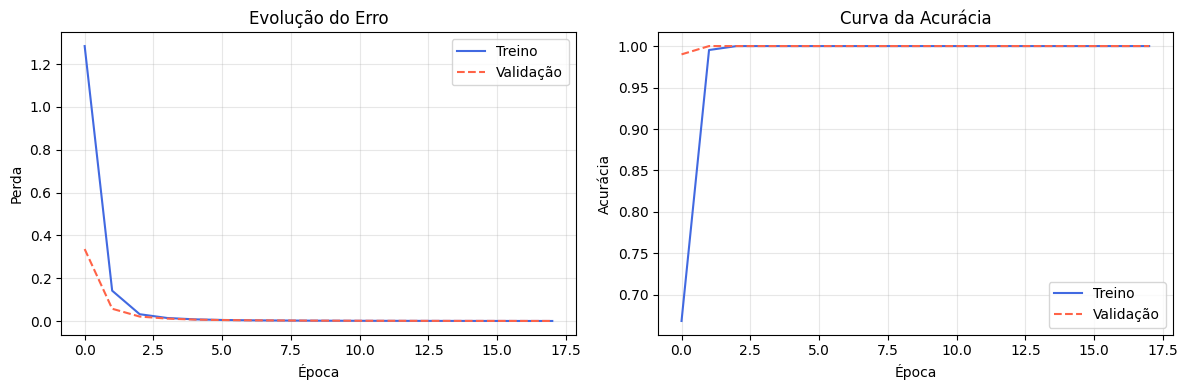

In [8]:
# Curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico.history['loss'],label='Treino',color='royalblue')
axes[0].plot(historico.history['val_loss'], label='Validação', color='tomato', linestyle='--')
axes[0].set_title('Evolução do Erro')
axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Perda')
axes[0].legend()

axes[1].plot(historico.history['accuracy'],label='Treino',color='royalblue')
axes[1].plot(historico.history['val_accuracy'], label='Validação', color='tomato', linestyle='--')
axes[1].set_title('Curva da Acurácia')
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()

plt.tight_layout()
plt.show()

**Comentário**: Os gráficos da evolução do erro para os conjuntos de treinamento e validação apresentaram comportamento coerente. É possível observar que o erro do conjunto de treinamento diminui progressivamente ao longo das épocas, indicando que a rede foi capaz de aprender os padrões presentes nos dados. O erro de validação apresentou comportamento semelhante, mantendo valores muito próximos aos observados no treinamento durante todo o processo.

Da mesma forma, as curvas de acurácia dos conjuntos de treinamento e validação apresentaram comportamento semelhante, atingindo valores próximos de 100% e permanecendo praticamente sobrepostas. Esse resultado indica que o modelo possui boa capacidade de generalização para dados não utilizados diretamente no treinamento.

Em relação à identificação de overfitting, não foram observados indícios significativos de superajuste, uma vez que o erro de validação não apresentou aumento relevante em relação ao erro de treinamento. Além disso, as curvas de acurácia permaneceram próximas ao longo de todas as épocas.

O critério de parada antecipada (Early Stopping) interrompeu o treinamento após 18 épocas, na última vez em o código foi rodado, pois não foi observada melhora significativa no erro de validação durante 5 épocas consecutivas. Dessa forma, foi evitada a execução desnecessária das demais épocas previstas (100 épocas), reduzindo o custo computacional do treinamento e preservando automaticamente os pesos correspondentes à época de melhor desempenho no conjunto de validação.

**5. Avaliação**

Após o treinamento, avalie o desempenho da rede exclusivamente no conjunto de teste.

In [9]:
perda, acuracia = modelo.evaluate(X_teste, T_teste, verbose=0)
erro_classificacao = 1 - acuracia
print(f'Perda no teste: {perda:.4f}')
print(f'Erro de classificação: {erro_classificacao:.2%}')
print(f'Acurácia no teste: {acuracia:.2%}')

Perda no teste: 0.0011
Erro de classificação: 0.00%
Acurácia no teste: 100.00%


**Comentário**: Os resultados obtidos no conjunto de teste demonstram o excelente desempenho do modelo, que alcançou acurácia de 100% e, consequentemente, erro de classificação de 0%. Esses resultados indicam que a rede neural foi capaz de classificar corretamente todos os exemplos do conjunto de teste, evidenciando boa capacidade de generalização para dados não utilizados durante o treinamento. Além disso, o valor da perda foi bastante reduzido (0,0011), reforçando a qualidade das previsões realizadas pelo modelo.

In [12]:
# Valores preditos com o conjuto de dados teste
predicoes = modelo.predict(X_teste)

y_pred = np.argmax(predicoes, axis=1)
y_real = np.argmax(T_teste.values, axis=1)

# Matriz de Confusão
print(confusion_matrix(y_real, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[50  0  0  0  0  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 50  0  0  0  0  0  0  0]
 [ 0  0  0 50  0  0  0  0  0  0]
 [ 0  0  0  0 50  0  0  0  0  0]
 [ 0  0  0  0  0 50  0  0  0  0]
 [ 0  0  0  0  0  0 50  0  0  0]
 [ 0  0  0  0  0  0  0 50  0  0]
 [ 0  0  0  0  0  0  0  0 50  0]
 [ 0  0  0  0  0  0  0  0  0 50]]


**Comentário Final**: Para a realização deste trabalho, foi utilizada a LLM ChatGPT como ferramenta de apoio ao desenvolvimento das atividades, principalmente na conferência dos resultados obtidos, no aprimoramento do código implementado e na revisão gramatical e ortográfica dos comentários apresentados.